# Декодирование сигналов Morse: Соревнование cryoarchive-incident
Этот ноутбук содержит решение для соревнования по декодированию искаженных сигналов азбуки Морзе.

In [ ]:
import os
import zipfile
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib
import kagglehub
import kagglehub.cache
import kagglehub.handle

SEED = 42
MIN_EPOCHS = 20
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2
DATASET_NAME = "cryoarchive-incident"
INTERACTIVE = True

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not INTERACTIVE:
    matplotlib.use("Agg")

## 1. Загрузка и подготовка датасета

In [ ]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")
    print(f"Вы авторизованы как пользователь: {username}")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
zip_file = DATA_DIR / "morse_dataset_public.zip"
extracted_dir = DATA_DIR / "morse_dataset_public"

if not extracted_dir.exists():
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

TRAIN_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "train"
TEST_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "test"
LABELS_CSV = TRAIN_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

## 2. Разведочный анализ данных (EDA)

(30000, 2)
    filename     text
0  00000.wav       83
1  00001.wav       68
2  00002.wav    41254
3  00003.wav     27-9
4  00004.wav  55-3991
Минимальная длина: 1
Максимальная длина: 9
Средняя длина: 4.54
Медианная длина: 5.00


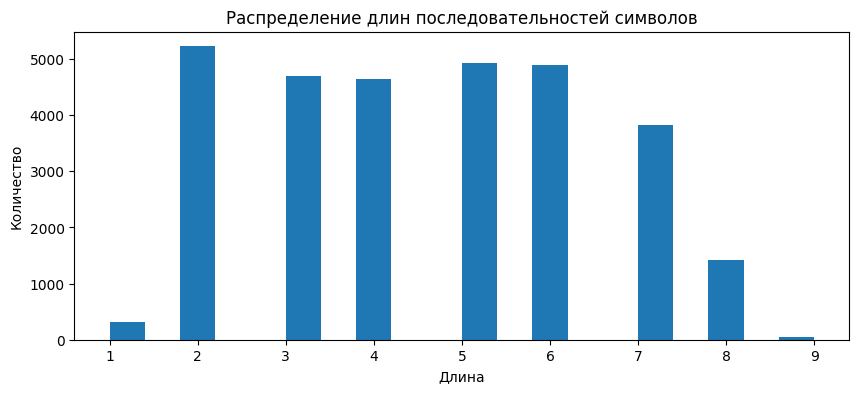

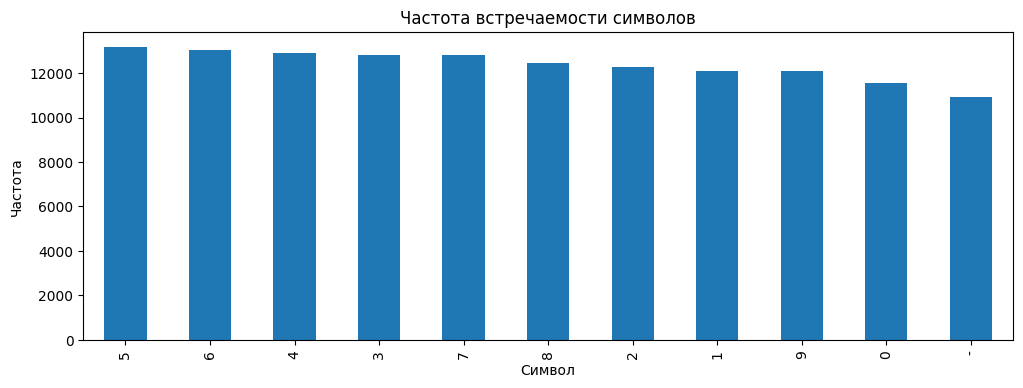

Частота дискретизации: 8000 Гц, Длина: 40000 отсчетов, Длительность: 5.00 сек
Уникальные частоты дискретизации: {8000}
Минимальная длительность: 5.00 сек, Максимальная: 5.00 сек
Минимальная RMS амплитуда: 4095.60, Максимальная: 4095.76


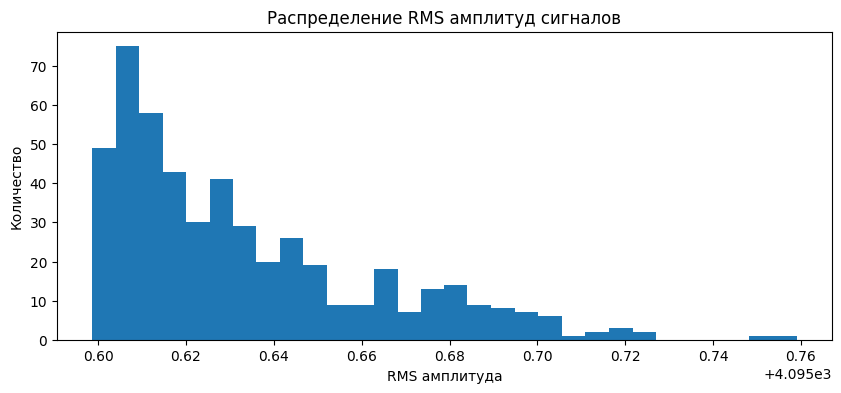

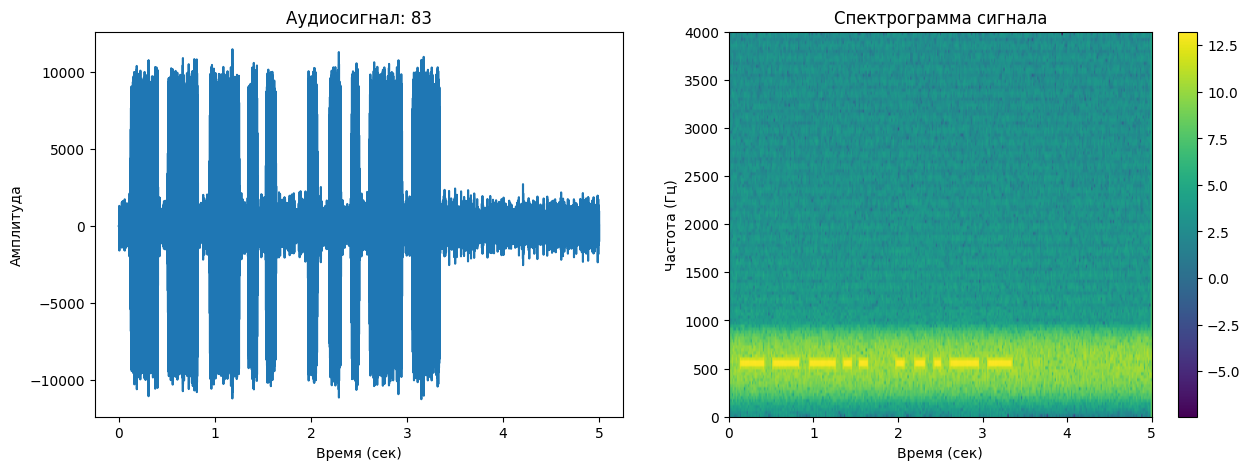

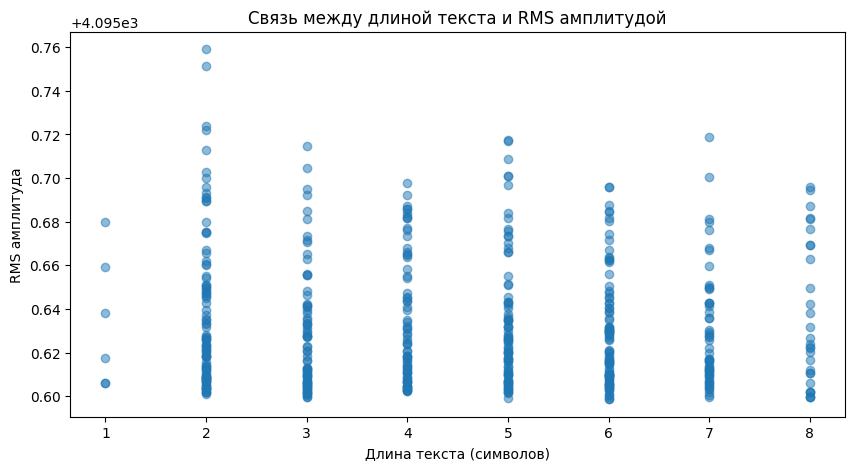

In [ ]:
df = pd.read_csv(LABELS_CSV)
print(df.shape)
print(df.head())

lengths = df["text"].astype(str).str.len()
print(f"Минимальная длина: {lengths.min()}")
print(f"Максимальная длина: {lengths.max()}")
print(f"Средняя длина: {lengths.mean():.2f}")
print(f"Медианная длина: {lengths.median():.2f}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=20)
plt.title("Распределение длин последовательностей символов")
plt.xlabel("Длина")
plt.ylabel("Количество")
plt.show()

all_chars = [char for text in df["text"].astype(str) for char in text]
char_counts = pd.Series(all_chars).value_counts()
plt.figure(figsize=(12, 4))
char_counts.plot(kind="bar")
plt.title("Частота встречаемости символов")
plt.xlabel("Символ")
plt.ylabel("Частота")
plt.show()

sample_filename = df.iloc[0]["filename"]
sample_wav = TRAIN_DIR / sample_filename
sr, y = wavfile.read(sample_wav)
print(f"Частота дискретизации: {sr} Гц, Длина: {len(y)} отсчетов, Длительность: {len(y)/sr:.2f} сек")

durations = []
rms_amplitudes = []
sample_rates = []
for idx in range(min(500, len(df))):
    wav_p = TRAIN_DIR / df.iloc[idx]["filename"]
    s_r, s_y = wavfile.read(wav_p)
    sample_rates.append(s_r)
    durations.append(len(s_y) / s_r)
    rms_amplitudes.append(np.sqrt(np.mean(s_y.astype(np.float32) ** 2)))

print(f"Уникальные частоты дискретизации: {set(sample_rates)}")
print(f"Минимальная длительность: {min(durations):.2f} сек, Максимальная: {max(durations):.2f} сек")
print(f"Минимальная RMS амплитуда: {min(rms_amplitudes):.2f}, Максимальная: {max(rms_amplitudes):.2f}")

plt.figure(figsize=(10, 4))
plt.hist(rms_amplitudes, bins=30)
plt.title("Распределение RMS амплитуд сигналов")
plt.xlabel("RMS амплитуда")
plt.ylabel("Количество")
plt.show()

y_tensor = torch.tensor(y, dtype=torch.float32)
window = torch.hann_window(256)
stft = torch.stft(y_tensor, n_fft=256, hop_length=128, win_length=256, window=window, return_complex=True)
spectrogram = torch.log(torch.abs(stft) + 1e-6).numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(np.linspace(0, len(y) / sr, len(y)), y)
axes[0].set_title(f"Аудиосигнал: {df.iloc[0]['text']}")
axes[0].set_xlabel("Время (сек)")
axes[0].set_ylabel("Амплитуда")

im = axes[1].imshow(spectrogram, aspect="auto", origin="lower", extent=[0, len(y)/sr, 0, sr/2])
axes[1].set_title("Спектрограмма сигнала")
axes[1].set_xlabel("Время (сек)")
axes[1].set_ylabel("Частота (Гц)")
plt.colorbar(im, ax=axes[1])
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(lengths[:500], rms_amplitudes, alpha=0.5)
plt.title("Связь между длиной текста и RMS амплитудой")
plt.xlabel("Длина текста (символов)")
plt.ylabel("RMS амплитуда")
plt.show()

## 3. Словарь символов и разделение выборки

In [ ]:
df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED)

all_chars = set()
for text in df["text"].astype(str):
    all_chars.update(text)
unique_chars = sorted(list(all_chars))

char_to_idx = {char: idx for idx, char in enumerate(unique_chars, start=1)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx) + 1

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер валидационной выборки: {len(val_df)}")
print(f"Уникальные символы в словаре ({len(unique_chars)}): {unique_chars}")

Размер обучающей выборки: 24000
Размер валидационной выборки: 6000
Уникальные символы в словаре (11): ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Класс датасета и загрузчик данных

In [ ]:
class MorseDataset(Dataset):
    def __init__(self, dataframe, audio_dir, is_test=False, mean=None, std=None):
        self.df = dataframe
        self.audio_dir = Path(audio_dir)
        self.filenames = dataframe["filename"].values
        self.texts = dataframe["text"].values if ("text" in dataframe.columns and not is_test) else None
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        wav_path = self.audio_dir / self.filenames[idx]
        sr, y = wavfile.read(wav_path)
        y = y.astype(np.float32)
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val
        y_tensor = torch.tensor(y, dtype=torch.float32)
        spectrogram = extract_features(y_tensor, self.mean, self.std)
        if self.texts is not None:
            text = self.texts[idx]
            label_indices = torch.tensor([char_to_idx[c] for c in str(text)], dtype=torch.long)
            return spectrogram.T, label_indices
        return spectrogram.T, self.filenames[idx]

def extract_features(y, mean=None, std=None):
    window = torch.hann_window(256)
    stft = torch.stft(y, n_fft=256, hop_length=128, win_length=256, window=window, return_complex=True)
    spectrogram = torch.log(torch.abs(stft) + 1e-6)
    if mean is not None and std is not None:
        spectrogram = (spectrogram - mean) / (std + 1e-8)
    return spectrogram

def compute_train_stats(dataset):
    sum_spec = torch.zeros(129)
    sq_sum_spec = torch.zeros(129)
    total_frames = 0
    for idx in tqdm(range(len(dataset)), desc="Вычисление статистик"):
        spec, _ = dataset[idx]
        sum_spec += spec.sum(dim=0)
        sq_sum_spec += (spec ** 2).sum(dim=0)
        total_frames += spec.size(0)
    mean = (sum_spec / total_frames).unsqueeze(1)
    std = torch.sqrt(torch.clamp(sq_sum_spec / total_frames - mean.squeeze(1) ** 2, min=1e-8)).unsqueeze(1)
    return mean, std

def collate_fn(batch):
    features = [item[0] for item in batch]
    input_lengths = torch.tensor([f.size(0) for f in features], dtype=torch.long)
    features_padded = nn.utils.rnn.pad_sequence(features, batch_first=True)

    if len(batch[0]) > 1 and isinstance(batch[0][1], torch.Tensor):
        labels = [item[1] for item in batch]
        target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
        labels_padded = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=0)
        return features_padded, labels_padded, input_lengths, target_lengths
    else:
        filenames = [item[1] for item in batch]
        return features_padded, filenames, input_lengths

train_dataset = MorseDataset(train_df, TRAIN_DIR)
mean, std = compute_train_stats(train_dataset)
train_dataset.mean = mean
train_dataset.std = std
torch.save({"mean": mean, "std": std}, "spectrogram_stats.pth")

val_dataset = MorseDataset(val_df, TRAIN_DIR, mean=mean, std=std)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Вычисление статистик:   0%|          | 0/24000 [00:00<?, ?it/s]

## 5. Архитектура модели

In [ ]:
class CRNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.rnn = nn.GRU(256, hidden_dim, num_layers=3, bidirectional=True, batch_first=True, dropout=0.3)
        self.fc_dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        x, _ = self.rnn(x)
        x = self.fc_dropout(x)
        x = self.fc(x)
        return x

def greedy_decode(output_probs):
    arg_maxes = torch.argmax(output_probs, dim=-1)
    decoded_sequences = []
    for seq in arg_maxes:
        decoded = []
        prev = -1
        for idx in seq:
            idx_val = idx.item()
            if idx_val != prev:
                if idx_val != 0:
                    decoded.append(idx_to_char[idx_val])
                prev = idx_val
        decoded_sequences.append("".join(decoded))
    return decoded_sequences

def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

NEG_INF = -float("inf")

def log_sum_exp(*args):
    res = args[0]
    for val in args[1:]:
        res = np.logaddexp(res, val)
    return res

def ctc_beam_search_decode(output_probs, beam_width=20, blank=0, prune_threshold=1e-5):
    import collections
    probs_np = output_probs.detach().cpu().numpy()
    decoded_sequences = []
    for probs in probs_np:
        T, S = probs.shape
        log_probs = np.log(np.clip(probs, 1e-12, 1.0))
        beam = {(): (0.0, NEG_INF)}
        for t in range(T):
            next_beam = collections.defaultdict(lambda: (NEG_INF, NEG_INF))
            active_s = np.argsort(probs[t])[-3:].tolist()
            active_s = [s for s in active_s if probs[t, s] > prune_threshold]
            if blank not in active_s:
                active_s.append(blank)
            for s in active_s:
                p = log_probs[t, s]
                for prefix, (p_b, p_nb) in beam.items():
                    if s == blank:
                        n_p_b, n_p_nb = next_beam[prefix]
                        n_p_b = log_sum_exp(n_p_b, p_b + p, p_nb + p)
                        next_beam[prefix] = (n_p_b, n_p_nb)
                    else:
                        n_prefix = prefix + (s,)
                        n_p_b, n_p_nb = next_beam[n_prefix]
                        if prefix and prefix[-1] == s:
                            n_p_nb = log_sum_exp(n_p_nb, p_b + p)
                            o_p_b, o_p_nb = next_beam[prefix]
                            o_p_nb = log_sum_exp(o_p_nb, p_nb + p)
                            next_beam[prefix] = (o_p_b, o_p_nb)
                        else:
                            n_p_nb = log_sum_exp(n_p_nb, p_b + p, p_nb + p)
                        next_beam[n_prefix] = (n_p_b, n_p_nb)
            beam = dict(sorted(next_beam.items(), key=lambda x: log_sum_exp(*x[1]), reverse=True)[:beam_width])
        best_prefix = max(beam.keys(), key=lambda x: log_sum_exp(*beam[x]))
        decoded_sequences.append("".join([idx_to_char[i] for i in best_prefix]))
    return decoded_sequences

## 6. Обучение и валидация

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRNNModel(input_dim=129, hidden_dim=256, output_dim=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    div_factor=5
)

best_lev = float("inf")
patience = 15
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for features, labels, input_lengths, target_lengths in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        outputs_log_probs = torch.log_softmax(outputs, dim=-1)
        outputs_log_probs = outputs_log_probs.transpose(0, 1)

        loss = criterion(outputs_log_probs, labels, input_lengths, target_lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * features.size(0)
        total_samples += features.size(0)

    epoch_loss = running_loss / total_samples

    model.eval()
    total_lev = 0.0
    total_chars = 0
    exact_matches = 0
    val_samples = 0

    with torch.no_grad():
        for features, labels, input_lengths, target_lengths in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            features = features.to(device)
            outputs = model(features)
            outputs_probs = torch.softmax(outputs, dim=-1)

            decoded_preds = greedy_decode(outputs_probs)

            for idx, pred in enumerate(decoded_preds):
                label_seq = labels[idx][:target_lengths[idx]].tolist()
                true_str = "".join([idx_to_char[i] for i in label_seq])
                lev = levenshtein_distance(pred, true_str)
                total_lev += lev
                total_chars += len(true_str)
                if lev == 0:
                    exact_matches += 1
                val_samples += 1

    epoch_lev = total_lev / val_samples
    epoch_cer = total_lev / max(1, total_chars)
    epoch_acc = exact_matches / val_samples
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f} - Val Levenshtein: {epoch_lev:.4f} - Val CER: {epoch_cer:.4f} - Val Accuracy: {epoch_acc:.4f}")

    if epoch_lev < best_lev:
        best_lev = epoch_lev
        torch.save(model.state_dict(), "best_crnn_model.pth")
        print("Сохранена лучшая модель")
        patience_counter = 0
    else:
        if epoch + 1 >= MIN_EPOCHS:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Ранняя остановка сработала на эпохе {epoch+1}")
                break

Epoch 1/100 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/100 - Loss: 6.0824 - Val Levenshtein: 4.5272 - Val CER: 1.0000 - Val Accuracy: 0.0000
Сохранена лучшая модель


Epoch 2/100 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 2/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 99/100 - Loss: 0.1159 - Val Levenshtein: 0.1772 - Val CER: 0.0391 - Val Accuracy: 0.9000


Epoch 100/100 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 100/100 - Loss: 0.1177 - Val Levenshtein: 0.1780 - Val CER: 0.0393 - Val Accuracy: 0.8980


## 7. Качественная оценка модели

In [8]:
model.load_state_dict(torch.load("best_crnn_model.pth", map_location=device))
model.eval()

true_strs = []
pred_strs = []
levs = []
true_lens = []
pred_lens = []

with torch.no_grad():
    for features, labels, input_lengths, target_lengths in val_loader:
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = ctc_beam_search_decode(outputs_probs)

        for idx, pred in enumerate(decoded_preds):
            label_seq = labels[idx][:target_lengths[idx]].tolist()
            true_str = "".join([idx_to_char[i] for i in label_seq])
            true_strs.append(true_str)
            pred_strs.append(pred)
            lev = levenshtein_distance(pred, true_str)
            levs.append(lev)
            true_lens.append(len(true_str))
            pred_lens.append(len(pred))

val_results = pd.DataFrame({
    "true": true_strs,
    "pred": pred_strs,
    "levenshtein": levs,
    "true_len": true_lens,
    "pred_len": pred_lens
})

In [ ]:
avg_lev = val_results["levenshtein"].mean()
total_chars = val_results["true_len"].sum()
total_lev = val_results["levenshtein"].sum()
cer = total_lev / max(1, total_chars)
accuracy = (val_results["levenshtein"] == 0).mean()

print(f"Среднее расстояние Левенштейна: {avg_lev:.4f}")
print(f"Character Error Rate (CER): {cer:.4f}")
print(f"Sequence Accuracy: {accuracy:.4f}")

In [10]:
def get_length_group(l):
    if l <= 4:
        return "Короткие (1-4)"
    elif l <= 8:
        return "Средние (5-8)"
    else:
        return "Длинные (9+)"

val_results["group"] = val_results["true_len"].apply(get_length_group)
group_stats = val_results.groupby("group").agg(
    count=("levenshtein", "count"),
    mean_levenshtein=("levenshtein", "mean"),
    accuracy=("levenshtein", lambda x: (x == 0).mean())
)
print("\nМетрики по группам длин:")
print(group_stats)


Метрики по группам длин:
                count  mean_levenshtein  accuracy
group                                            
Длинные (9+)       14          0.785714  0.714286
Короткие (1-4)   2957          0.077443  0.942171
Средние (5-8)    3029          0.269066  0.857049


In [11]:
print("\nТоп-10 худших предсказаний:")
val_results.sort_values(by="levenshtein", ascending=False).head(10)


Топ-10 худших предсказаний:


,true,pred,levenshtein,true_len,pred_len,group
3301,521415-54,00-,8,9,3,Длинные (9+)
1880,083-846,77,7,7,2,Средние (5-8)
366,794628-8,4-1072,7,8,6,Средние (5-8)
4579,140-87,353396,6,6,6,Средние (5-8)
4601,69-33-7,6691,6,7,4,Средние (5-8)
831,829-8757,4-773,6,8,5,Средние (5-8)
1377,66544440,44,6,8,2,Средние (5-8)
4094,021183,70-54,6,6,5,Средние (5-8)
5291,42-5213,3785723,5,7,7,Средние (5-8)
3738,42587515,359551,5,8,6,Средние (5-8)


In [12]:
def get_alignment_errors(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + 1)
    substitutions = []
    i, j = m, n
    while i > 0 or j > 0:
        if i > 0 and j > 0 and s1[i-1] == s2[j-1]:
            i -= 1
            j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            substitutions.append((s1[i-1], s2[j-1]))
            i -= 1
            j -= 1
        elif i > 0 and (j == 0 or dp[i][j] == dp[i-1][j] + 1):
            i -= 1
        else:
            j -= 1
    return substitutions

all_subs = []
for _, row in val_results.iterrows():
    all_subs.extend(get_alignment_errors(row["true"], row["pred"]))

if all_subs:
    sub_counts = pd.Series(all_subs).value_counts()
    print("\nТоп-10 наиболее частых замен символов:")
    for (true_c, pred_c), count in sub_counts.head(10).items():
        print(f"Истинный: '{true_c}' -> Предсказанный: '{pred_c}' | Количество: {count}")


Топ-10 наиболее частых замен символов:
Истинный: '4' -> Предсказанный: '5' | Количество: 36
Истинный: '7' -> Предсказанный: '6' | Количество: 34
Истинный: '2' -> Предсказанный: '3' | Количество: 33
Истинный: '0' -> Предсказанный: '1' | Количество: 31
Истинный: '1' -> Предсказанный: '2' | Количество: 30
Истинный: '9' -> Предсказанный: '8' | Количество: 27
Истинный: '3' -> Предсказанный: '4' | Количество: 27
Истинный: '0' -> Предсказанный: '9' | Количество: 27
Истинный: '2' -> Предсказанный: '1' | Количество: 26
Истинный: '6' -> Предсказанный: '5' | Количество: 25


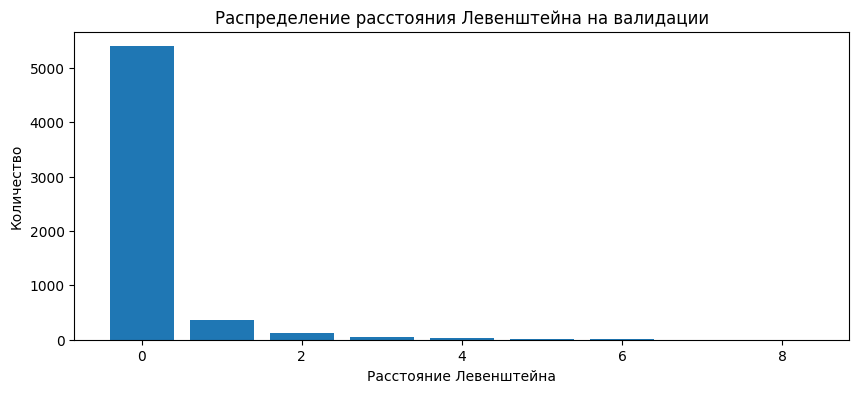

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(val_results["levenshtein"], bins=range(0, int(val_results["levenshtein"].max()) + 2), align="left", rwidth=0.8)
plt.title("Распределение расстояния Левенштейна на валидации")
plt.xlabel("Расстояние Левенштейна")
plt.ylabel("Количество")
plt.show()

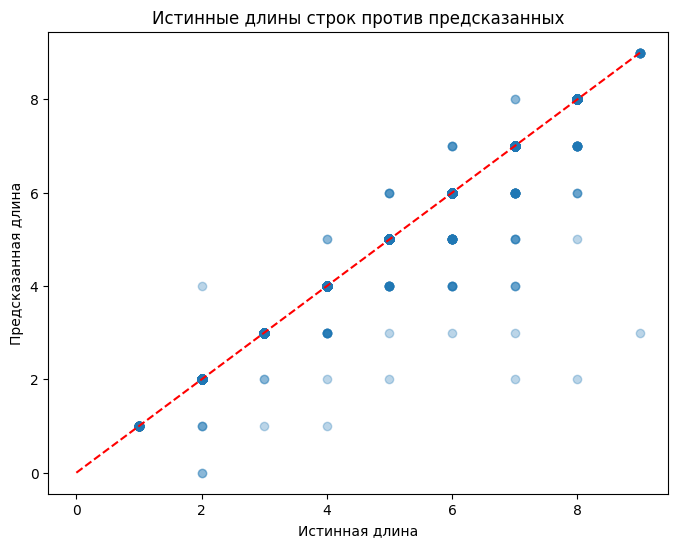

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(val_results["true_len"], val_results["pred_len"], alpha=0.3)
plt.plot([0, val_results["true_len"].max()], [0, val_results["true_len"].max()], "r--")
plt.title("Истинные длины строк против предсказанных")
plt.xlabel("Истинная длина")
plt.ylabel("Предсказанная длина")
plt.show()

## 8. Инференс на тестовой выборке и генерация сабмишна

In [ ]:
test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
stats = torch.load("spectrogram_stats.pth", map_location="cpu")
test_dataset = MorseDataset(test_df, TEST_DIR, is_test=True, mean=stats["mean"], std=stats["std"])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = CRNNModel(input_dim=129, hidden_dim=256, output_dim=num_classes).to(device)
model.load_state_dict(torch.load("best_crnn_model.pth", map_location=device))
model.eval()

predictions = []
filenames_list = []

with torch.no_grad():
    for features, filenames, input_lengths in tqdm(test_loader, desc="Inference"):
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = ctc_beam_search_decode(outputs_probs)
        predictions.extend(decoded_preds)
        filenames_list.extend(filenames)

submission = pd.DataFrame({
    "filename": filenames_list,
    "text": predictions
})
submission.to_csv("submission.csv", index=False)
print("Файл submission.csv успешно сохранен.")

Inference:   0%|          | 0/157 [00:00<?, ?it/s]

## 9. Проверка сабмишна

In [ ]:
sub = pd.read_csv("submission.csv", keep_default_na=False)
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")